# Solve Helmholtz equation with SA PINNs 

In [11]:
import torch 
from torch import nn 
from collections import OrderedDict # To place the hidden layers orderly 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspce 
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from Helmholtz_utils import * 
from utils.SA_PINN_structure import * 
import warnings

warnings.filterwarnings('ignore') # Import the built-in Python warnings module, and tell Python to ignore all warning messages.”
import time 



In [12]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available():
    device = torch.device('cuda') 
else:
    device = torch.device('cpu') 
# 
print(f"Working on {device}") 

Working on mps


# Self-Adaptive Physics-informed Neural Network 

In [13]:
class AdaptiveLoss(nn.Module): 
    def __init__(self, layers, N_r, N_b, N_0): 
        super(AdaptiveLoss, self).__init__()

        # Layers 
        self.depth = len(layers) - 1 # total layers, including the input and out put layers 

        # Self Adaptive parameters 
        # The parameters will be included in adaptive_loss.parameters() 
        self.lambda_r = nn.Parameter(torch.rand(N_r, 1), requires_grad = True) 
        self.lambda_b = nn.Parameter(torch.rand(N_b, 1), requires_grad = True) 
        self.lambda_0 = nn.Parameter(torch.rand(N_0, 1), requires_grad = True) 
        

        # Set up layer order dict 
        self.activation = nn.Tanh() 

        layer_list = list() 
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, nn.Linear(layers[i], layers[i+1])) 
            ) 
            layer_list.append(('activation_%d' % i, self.activation)) 

        layer_list.append( 
            ('layer_%d' % (self.depth - 1), nn.Linear(layers[-2], layers[-1])) 
        ) 
        layerDict = OrderedDict(layer_list) 

        # deploy layers 
        self.layers = nn.Sequential(layerDict) 

    def forward(self, x): 
        out = self.layers(x) 
        return out 

In [14]:
# the physics-informed neural network 
class SA_PINN_Helmholtz(): 
    def __init__(self, X_train, X_bc, layers, lb, ub,  N_r = 4800, N_b = 400, N_0 = 0, a1 = 1, a2 = 4, k = 1):  
        # boundary conditions: domain bounds 
        self.lb = torch.as_tensor(lb).float().to(device) 
        self.ub = torch.as_tensor(ub).float().to(device) 

        # Initial setup    
        self.N_r = N_r
        self.N_b = N_b
        self.k = k 
        self.a1 = a1 
        self.a2 = a2 

        self.X_train = torch.as_tensor(X_train, dtype = torch.float32).to(device) 
        self.X_train.requires_grad_(True) 
        self.N_int = self.X_train.shape[0]


        # Boundary data points for periodic boundary conditions 
        self.BC_left = torch.tensor(X_bc[:,0:2]).float().to(device) 
        self.BC_right = torch.tensor(X_bc[:,2:4]).float().to(device) 
        self.BC_down = torch.tensor(X_bc[:, 4:6]).float().to(device) 
        self.BC_up = torch.tensor(X_bc[:, 6:8]).float().to(device) 
        self.N_bc = self.BC_left.shape[0]
        # deep neural network 
        self.dnn = AdaptiveLoss(layers, N_r, N_b, N_0).to(device) 
        

        
        # optimizers: using the same settings 
        self.optimizer = torch.optim.LBFGS( # requires multiple evaluation of the loss function per iteration 
            self.dnn.layers.parameters(),    # target to be optimized 
            lr = 1.0,    # learning rate: step length 
            max_iter = 1,    # maximum number of iterations 
            max_eval = 500000,    # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 0.0, 
            tolerance_change = 0.0, # 1.0 * np.finfo(float).eps,   # If the absolute change in the loss is smaller than tolerance_change, the optimizer 
            # assumes it has converged, and stops early. 
            line_search_fn = "strong_wolfe"      # "strong wolfe condition
        ) 
        
        self.optimizer_Adam = torch.optim.Adam(self.dnn.layers.parameters(), lr = 2e-4, betas = (0.9, 0.999))
        self.optimizer_Adam_r = torch.optim.Adam([self.dnn.lambda_r], lr = 5e-4, betas = (0.9, 0.999)) # Optimizers always take lists / iterables, never single tensors directly
        self.optimizer_Adam_b = torch.optim.Adam([self.dnn.lambda_b], lr = 5e-4, betas = (0.9, 0.999)) 

        # Record the iteration number 
        self.iter = 0 
    
    
    def net_u(self, X): # predicted value 
        u = self.dnn(X)
        return u 

    def q(self, X): 
        a1 = self.a1 * torch.pi 
        a2 = self.a2 * torch.pi 
        return (self.k ** 2 - a1 ** 2 - a2 ** 2) * torch.sin(a1 * X[:, 0:1]) * torch.sin(a2 * X[:, 1:2])   

    def PDE_residual(self, X): 
        u = self.net_u(X) 
        q = self.q(X) 
        
        grad_u = torch.autograd.grad(
            outputs = u, 
            inputs = X, 
            grad_outputs = torch.ones_like(u),
            create_graph = True
        )[0] # shape (N, 2) 

        u_x = grad_u[:, 0:1] 
        u_y = grad_u[:, 1:2]  
        
        u_xx = torch.autograd.grad(
            u_x, X, 
            grad_outputs = torch.ones_like(u_x), 
            create_graph = True
        )[0][:, 0:1]

        u_yy = torch.autograd.grad(
            u_y, X, 
            grad_outputs = torch.ones_like(u_y),
            create_graph = True 
        )[0][:, 1:2]
            
        # PDE residual loss 
        f = u_xx + u_yy + (self.k ** 2) * u - q    
        return f 
    
    def loss_func(self, X_int, BC_left, BC_right, BC_down, BC_up, lambda_r, lambda_b): 

        f_pred = self.PDE_residual(X_int) 
        u_left = self.net_u(BC_left) 
        u_right = self.net_u(BC_right) 
        u_down = self.net_u(BC_down) 
        u_up = self.net_u(BC_up) 
        
        mse_r_u = torch.pow(f_pred, 2) 

        mse_b_u_left = torch.pow(u_left, 2) 
        mse_b_u_right = torch.pow(u_right, 2) 
        mse_b_u_down = torch.pow(u_down, 2)
        mse_b_u_up = torch.pow(u_up, 2) 

        lb_detach = lambda_b.detach()
        mse_b_u = torch.mean(torch.pow(lb_detach[:self.N_bc], 2) * mse_b_u_left) + torch.mean(torch.pow(lb_detach[self.N_bc: 2 * self.N_bc], 2) * mse_b_u_right) 
        + torch.mean(torch.pow(lb_detach[2 * self.N_bc: 3 * self.N_bc], 2) * mse_b_u_down) + torch.mean(torch.pow(lb_detach[3 * self.N_bc: 4 * self.N_bc], 2) * mse_b_u_up)

        mse_b_u_detach = torch.mean(torch.pow(lambda_b[:self.N_bc], 2) * mse_b_u_left.detach()) + torch.mean(torch.pow(lambda_b[self.N_bc: 2 * self.N_bc], 2) * mse_b_u_right.detach()) 
        + torch.mean(torch.pow(lambda_b[2 * self.N_bc: 3 * self.N_bc], 2) * mse_b_u_down.detach()) + torch.mean(torch.pow(lambda_b[3 * self.N_bc: 4 * self.N_bc], 2) * mse_b_u_up.detach())
            
        return (
            mse_b_u + torch.mean(torch.pow(lambda_r.detach(), 2) * mse_r_u),
            mse_b_u_detach, 
            torch.mean(torch.pow(lambda_r, 2) * mse_r_u.detach()),
        )
   
    # For the optimization of LBFGS 
    def closure(self): 
        loss_value, mse_b, mse_r = self.loss_func(self.X_train, self.BC_left, self.BC_right, self.BC_down, self.BC_up, self.dnn.lambda_r, self.dnn.lambda_b) 
        self.optimizer.zero_grad()     # reset gradients
        loss_value.backward()          # compute gradients but only the network weights will be updated 
        return loss_value  
    
    def Optimize(self, Iter1, Iter2):
        self.dnn.train()
        # Backward and optimize: 2nd phase optimization 
        # Two Phase optimization
        
        for epoch in range(Iter1):
            
            loss_value, mse_b, mse_r = self.loss_func(self.X_train, self.BC_left, self.BC_right, self.BC_down, self.BC_up, self.dnn.lambda_r, self.dnn.lambda_b)  

            # Network parameter update 
            self.optimizer_Adam.zero_grad()
            
            # self.optimizer_Muon.zero_grad()
            loss_value.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 

            self.optimizer_Adam_r.zero_grad() 
            self.optimizer_Adam_b.zero_grad() 

            (- mse_b).backward() 
            (- mse_r).backward()
            
            self.optimizer_Adam_b.step() # only sees the gradient of lambda_r  
            self.optimizer_Adam_r.step() # only sees the gradient of lambda_0 
            
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss_value.item()
                    )
                )

        for i in range(Iter2): 
            self.optimizer.step(self.closure) # Never pass tensors into optimizer.step()
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))

    def predict(self, X):
        X = torch.as_tensor(X, dtype = torch.float32, device = device)  
        X.requires_grad_(True) 

        self.dnn.eval()
        with torch.no_grad():
            u = self.net_u(X) 
        f = self.PDE_residual(X) 
        
        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy() 
        return u, f

# Configurations 

In [15]:
# Domain bounds 
lb = np.array([-1.0, -1.0]) 
ub = np.array([1.0, 1.0]) 

k = 1
a1 = 1 
a2 = 4
                                               

# Grid point setup 
N_bc = 100
N_x = 40 
N_y = 120 


# Training points 
X_train_int = interior_points(N_x, N_y, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")

X_train_bc = bc_points(N_bc, lb[0], ub[0], lb[1], ub[1])
print(f"X_train_bc shape: {np.shape(X_train_bc)}") 



X_train_int shape: (4800, 2)
X_train_bc shape: (100, 8)


# Generate Test data and solution  

In [16]:
# Generate test data 
N = 100
X_test, u_test = test_data(N) 

print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Trainging on Non-noisy Data

In [17]:
# torch.manual_seed(42) 
noise = 0.0 
layers = [2, 50, 50, 50, 50, 1] 
Nr = 4800 
Nb = 400 
N_0 = 0 

# training 
model = SA_PINN_Helmholtz(X_train_int, X_train_bc, layers, lb, ub, Nr, Nb, N_0) 
start = time.time()
model.Optimize(10000, 500) 
end = time.time() 

It: 0, Loss: 2.048e+03
It: 100, Loss: 2.364e+03
It: 200, Loss: 2.654e+03
It: 300, Loss: 2.720e+03
It: 400, Loss: 2.933e+03
It: 500, Loss: 3.006e+03
It: 600, Loss: 2.223e+03
It: 700, Loss: 1.802e+03
It: 800, Loss: 1.306e+03
It: 900, Loss: 3.312e+02
It: 1000, Loss: 1.242e+02
It: 1100, Loss: 7.718e+01
It: 1200, Loss: 5.648e+01
It: 1300, Loss: 4.305e+01
It: 1400, Loss: 3.257e+01
It: 1500, Loss: 2.410e+01
It: 1600, Loss: 1.765e+01
It: 1700, Loss: 1.309e+01
It: 1800, Loss: 9.988e+00
It: 1900, Loss: 7.835e+00
It: 2000, Loss: 6.294e+00
It: 2100, Loss: 5.143e+00
It: 2200, Loss: 4.262e+00
It: 2300, Loss: 3.571e+00
It: 2400, Loss: 3.023e+00
It: 2500, Loss: 2.587e+00
It: 2600, Loss: 2.250e+00
It: 2700, Loss: 1.960e+00
It: 2800, Loss: 1.733e+00
It: 2900, Loss: 1.550e+00
It: 3000, Loss: 1.400e+00
It: 3100, Loss: 1.297e+00
It: 3200, Loss: 1.169e+00
It: 3300, Loss: 1.080e+00
It: 3400, Loss: 1.001e+00
It: 3500, Loss: 9.484e-01
It: 3600, Loss: 8.762e-01
It: 3700, Loss: 8.071e-01
It: 3800, Loss: 7.558e-0

# Test the accuracy 

In [18]:
# evaluations 
u_pred, f_pred = model.predict(X_test)  

print(f"u_pred shape: {np.shape(u_pred)}") 
# print(f"f_pred shape: {np.shape(f_pred)}")  
print(f"u_test shape: {np.shape(u_test)}") 

error_u = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
# error_f = np.linalg.norm(abs(f_pred), ord = np.inf) 


print('Error u: %e' % (error_u)) 
# print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end - start:.2f} seconds')



u_pred shape: (10000, 1)
u_test shape: (10000, 1)
Error u: 2.698858e+00
Training time is 156.58 seconds


# Collect Error Data 

In [8]:
# torch.manual_seed(42)
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
k = 1 
a1 = 1
a2 = 4
Nr = 4800
Nb = 400 
# Training points 
training_sets = np.load(
    "Helmholtz_2d_training_points_4800_sets.npy",
    allow_pickle=True
)
layers = [2, 50, 50, 50, 50, 1]

for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_bc = data["X_train_bc"] 
    model = SA_PINN_Helmholtz(X_train_int, X_train_bc, layers, lb, ub, Nr, Nb)
    start = time.time() 
    model.Optimize(10000, 500) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) 
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 2.374e+03
It: 100, Loss: 2.742e+03
It: 200, Loss: 2.940e+03
It: 300, Loss: 2.696e+03
It: 400, Loss: 2.706e+03
It: 500, Loss: 2.910e+03
It: 600, Loss: 2.764e+03
It: 700, Loss: 2.903e+03
It: 800, Loss: 3.217e+03
It: 900, Loss: 3.464e+03
It: 1000, Loss: 3.687e+03
It: 1100, Loss: 3.993e+03
It: 1200, Loss: 4.264e+03
It: 1300, Loss: 4.430e+03
It: 1400, Loss: 4.605e+03
It: 1500, Loss: 4.952e+03
It: 1600, Loss: 5.244e+03
It: 1700, Loss: 4.386e+03
It: 1800, Loss: 1.610e+03
It: 1900, Loss: 3.337e+02
It: 2000, Loss: 1.998e+02
It: 2100, Loss: 1.488e+02
It: 2200, Loss: 1.191e+02
It: 2300, Loss: 8.698e+01
It: 2400, Loss: 5.506e+01
It: 2500, Loss: 3.491e+01
It: 2600, Loss: 2.317e+01
It: 2700, Loss: 1.602e+01
It: 2800, Loss: 1.141e+01
It: 2900, Loss: 8.422e+00
It: 3000, Loss: 6.476e+00
It: 3100, Loss: 5.151e+00
It: 3200, Loss: 4.223e+00
It: 3300, Loss: 3.544e+00
It: 3400, Loss: 3.036e+00
It: 3500, Loss: 2.643e+00
It: 3600, Loss: 2.334e+00
It: 3700, Loss: 2.087e+00
It: 3800, Loss: 1.894e+0

In [9]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

[1.14563245 1.35300373 1.31371774 1.0588794  1.11943598 1.5472865
 3.20024683 2.64598712 1.53024105 2.73301539]
1.7647446198161958
0.7448495015612178
3.0079260614961822
1.0088240757380886
157.01598768234254
1.4645036545495007


In [118]:
# Save the results 
results = {
    "Model": "SA_PINN",
    "Layers": [2, 50, 50, 50, 50, 1], 
    "Training_points_int_bc": [N_x, N_y, N_bc], 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Helmholtz_SA_PINN_4800_training_data.pt")

# Visualization 

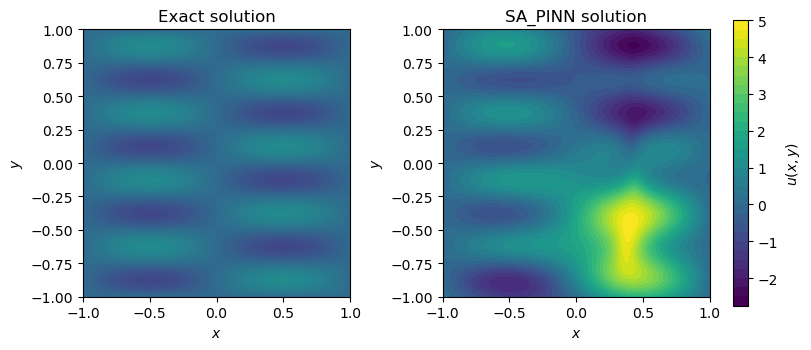

In [19]:
import matplotlib.gridspec as gridspec 


# Predicted solution
U_pred = u_pred.reshape(N, N)
U_true = u_test.reshape(N, N) 
XX = X_test[:, 0:1].reshape(N, N) 
YY = X_test[:, 1:2].reshape(N, N) 
# Use the same color scale for both plots
vmin = min(U_true.min(), U_pred.min())
vmax = max(U_true.max(), U_pred.max())

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 3.5),
    constrained_layout=True
)

# -----------------------------
# Exact solution
# -----------------------------
contour0 = axes[0].contourf(
    XX, YY, U_true,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
axes[0].set_title("Exact solution")
axes[0].set_aspect("equal")

# -----------------------------
# Random feature solution
# -----------------------------
contour1 = axes[1].contourf(
    XX, YY, U_pred,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
axes[1].set_title("SA_PINN solution")
axes[1].set_aspect("equal")

# -----------------------------
# Shared colorbar
# -----------------------------
cbar = fig.colorbar(
    contour1,
    ax=axes,
    shrink=0.9,
    pad=0.02
)
cbar.set_label(r"$u(x,y)$")

# -----------------------------
# Save figure
# -----------------------------
""" 
fig.savefig(
    "Helmholtz_solution_SA_PINN.pdf",
    bbox_inches="tight"
)
""" 

plt.show()

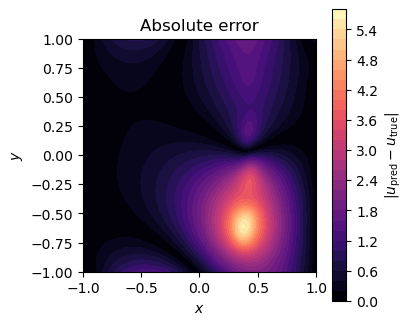

In [20]:
# Absolute error
error = np.abs(U_pred - U_true)

# Create figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 3.5),
    constrained_layout=True
)

# -----------------------------
# Absolute error
# -----------------------------
contour = ax.contourf(
    XX, YY, error,
    levels=30,
    cmap="magma"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Absolute error")
ax.set_aspect("equal")

# -----------------------------
# Colorbar
# -----------------------------
cbar = fig.colorbar(
    contour,
    ax=ax,
    shrink=0.9,
    pad=0.02
)
cbar.set_label(r"$|u_{\mathrm{pred}}-u_{\mathrm{true}}|$")

# -----------------------------
# Save figure
# -----------------------------
"""
fig.savefig(
    "Helmholtz_error_SA_PINN.pdf",
    bbox_inches="tight"
)
"""

plt.show()